In [1]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier,plot_tree 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_promo = {
    'Experience_Years':[2,4,5,3,6,5],
    'Performance_Rating':[3,4,5,3,4,4],
    'Promoted':['No','Yes','Yes','No','Yes',None]
}
df=pd.DataFrame(data_promo)
print('Dataset:')
display(df)

Dataset:


,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,5,5,Yes
3,3,3,No
4,6,4,Yes
5,5,4,None


In [4]:
#1 Clean the data

train_df = df.dropna()
train_df

,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,5,5,Yes
3,3,3,No
4,6,4,Yes


In [5]:
#2 Split data find input and output

x = train_df[['Experience_Years','Performance_Rating']]
y = train_df['Promoted']

In [6]:
#3 Create the model

model = DecisionTreeClassifier()

In [9]:
#4 Train the model

model.fit(x,y)

DecisionTreeClassifier()

In [20]:
# 5 Prediction
pred_promote = model.predict([[5,4]])[0]
print('Promotion prediction:',pred_promote[0])

Promotion prediction: Y


C:\Users\Faridah\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


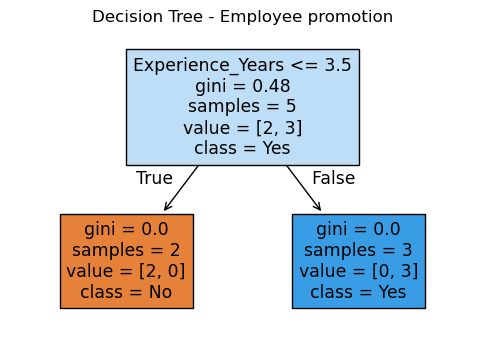

In [12]:
plt.figure(figsize=(6,4))
plot_tree(model,
          feature_names=['Experience_Years','Performance_Rating'],
          class_names=['No','Yes'],
          filled=True)
plt.title('Decision Tree - Employee promotion')
plt.show()

# Exercise 1
### take the exp. years and performance rating from user and display Promoted or not promoted using prediction
### write code in this way, there shoud be no warning sign

### exp_years =
### perf_rating =
### print('Promoted?')

In [15]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier,plot_tree 
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
data_promo = {
    'Experience_Years':[2,4,5,3,6,5],
    'Performance_Rating':[3,4,5,3,4,4],
    'Promoted':['No','Yes','Yes','No','Yes',None]
}
df=pd.DataFrame(data_promo)
print('Dataset:')
display(df)

#1 Clean the data
train_df = df.dropna()
train_df

#2 Split data find input and output
x = train_df[['Experience_Years','Performance_Rating']]
y = train_df['Promoted']

#3 Create the model
model = DecisionTreeClassifier()

#4 Train the model
model.fit(x,y)

# 5 Prediction
exp_years = input('How many years have you served for the company?\t')
perf_rating = input('What is your performance rating?\t')
our_employee = pd.DataFrame([[exp_years,perf_rating]], columns=['Experience_Years','Performance_Rating'])
pred_promote = model.predict(our_employee)[0]
print('Promoted?\t',pred_promote[0])


Dataset:


,Experience_Years,Performance_Rating,Promoted
0,2,3,No
1,4,4,Yes
2,5,5,Yes
3,3,3,No
4,6,4,Yes
5,5,4,None


How many years have you served for the company?	 5
What is your performance rating?	 8


Promoted?	 Y


## One more example on DecisionTreeClassifier

In [50]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [51]:
data = { 'Age': [25, 30, 45, 35, 22, 40, 50],
        'Income': ['Low','Medium','High','Medium','Low','High','High'],
        'Buy': ['No','No','Yes','Yes','No','Yes','Yes']
       }

In [52]:
df=pd.DataFrame(data)
print('Dataset:')
display(df)

#1 Clean the data and use label encoder if necessary
train_df = df.dropna()
train_df

encoder = OneHotEncoder(sparse_output=False)
income_encoded = encoder.fit_transform(df[['Income']])
income_encoded_df = pd.DataFrame(income_encoded, columns = encoder.get_feature_names_out(['Income']))

le=LabelEncoder()
df['Buy'] = le.fit_transform(df['Buy'])

df_encoded=pd.concat([df[['Age','Buy']], income_encoded_df], axis=1)
df_encoded

#2 Split data find input and output
x = df_encoded.drop('Buy',axis=1)
y = df_encoded['Buy']

#3 Create the model
model = DecisionTreeClassifier()

#4 Train the model
model.fit(x,y)


Dataset:


,Age,Income,Buy
0,25,Low,No
1,30,Medium,No
2,45,High,Yes
3,35,Medium,Yes
4,22,Low,No
5,40,High,Yes
6,50,High,Yes


DecisionTreeClassifier()

In [53]:
#5 Prediction

sample=pd.DataFrame({'Age':[28],'Income':['Medium']})
sample_encoded=encoder.transform(sample[['Income']])

sample_encoded_df=pd.DataFrame(sample_encoded, columns=encoder.get_feature_names_out(['Income']))

sample_final = pd.concat([sample[['Age']],sample_encoded_df], axis=1)

prediction = model.predict(sample_final)
predicted_label = le.inverse_transform(prediction)
print('Prediction for Age=28, Income=Medium is:\t',predicted_label[0])

Prediction for Age=28, Income=Medium is:	 No


In [56]:
# 5 Prediction by taking input
person_age=int(input('Enter Age'))
person_income=input('Enter category Low,Medium or High :\t')
person=pd.DataFrame({'Age':[person_age],'Income':[person_income]})
person_encoded = le.transform(person[['Income']])
person_encoded_df = pd.DataFrame(person_encoded, columns=encoder.get_feature_names_out(['Income']))
person_final = pd.concat([person['Age'], person_encoded_df], axis=1)
prediction = model.predict(person_final)
predicted_label = label_encoder.inverse_transform(prediction)
print(f'Prediction for Age={person_age}, Income={person_income} → { predicted_label[0]}')


Enter Age 33
Enter category Low,Medium or High :	 56777


C:\Users\Faridah\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


ValueError: y contains previously unseen labels: '56777'